In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data load

In [3]:
subset_1 = pd.read_csv('/content/drive/MyDrive/lmf/data/04_30_2026_sample_8_across_subsets_1_2_3/subset_1_gas_sorted_by_sql.csv')
subset_2 = pd.read_csv('/content/drive/MyDrive/lmf/data/04_30_2026_sample_8_across_subsets_1_2_3/subset_2_gas_sorted_by_sql.csv')
subset_3 = pd.read_csv('/content/drive/MyDrive/lmf/data/04_30_2026_sample_8_across_subsets_1_2_3/subset_3_gas_sorted_by_sql.csv')

#Data visualization and count of batchs numbers

In [4]:
#Header appearance
subset_1.head(2)

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm
0,1,3,Genetic bank,F24-3416,ABC-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,...,28.172715,62.577353,4.000526,11.156690,14.2,17.828639,135.945555,227.8476704,37.051645,65.414752
1,1,4,Genetic bank,F24-3416,ABC-705,Fabales,Fabaceae,Indigofera,suffruticosa,Indigofera suffruticosa,...,28.172715,61.249843,4.225907,11.205181,15,18.294220,133.168047,270.0095702,38.185077,63.799940


In [5]:
#Number of laboratory batchs
print('Number of laboratory batchs, Subset 1: ', len(subset_1.batch.unique()))
print('Number of laboratory batchs, Subset 2: ', len(subset_2.batch.unique()))
print('Number of laboratory batchs, Subset 3: ', len(subset_3.batch.unique()))

Number of laboratory batchs, Subset 1:  28
Number of laboratory batchs, Subset 2:  28
Number of laboratory batchs, Subset 3:  11


# Dataframe preparation

In [6]:
#Compilation of all subsets
combined_subsets = pd.concat([subset_1, subset_2, subset_3], ignore_index=True)
combined_subsets.tail(2)

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm
6007,3,1284,LMF,F25-2134,Hohenheimer Heustandard IAG 2025/1 S1,Green meal,Heustandard,Hohenheimer,Heustandard,Hohenheimer Heustandard,...,29.049977,46.399325,3.950797,6.882837,13.6,14.833915,203.209392,#DIV/0!,61.217457,49.240708
6008,3,1285,LMF,F25-2134,Hohenheimer Heustandard IAG 2025/1 S1,Green meal,Heustandard,Hohenheimer,Heustandard,Hohenheimer Heustandard,...,27.549977,45.399325,3.856997,6.962783,14.0,15.336755,198.829815,#DIV/0!,98.299163,31.021670


In [7]:
# Extracting Samples 8, id_lab 'F25-0019'
df = combined_subsets[combined_subsets['id'] == 'Sample 8']
df

,subset,no,requisitioner,id_lab,id,tax_order,family,genus,species,tax_name,...,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm
753,1,677,LMF,F25-0019,Sample 8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,22.457046,60.678276,3.840155,11.331516,17.1,18.674749,129.447427,#DIV/0!,50.373843,47.989157
754,1,678,LMF,F25-0019,Sample 8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,20.687033,59.350766,3.496109,11.074200,16.9,18.6589,126.514205,#DIV/0!,48.823020,48.350469
755,1,679,LMF,F25-0019,Sample 8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,23.342053,62.005786,3.524650,11.102742,15.1,17.905977,132.173741,#DIV/0!,45.893637,51.569239
816,1,739,LMF,F25-0019,Sample 8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,23.342053,59.350766,4.318280,11.556031,18.5,19.470736,126.564780,#DIV/0!,48.324122,50.995432
817,1,740,LMF,F25-0019,Sample 8,Poales,Poaceae,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,24.669563,40.765624,4.613208,7.832420,18.7,19.213297,86.949572,#DIV/0!,33.609460,49.705886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5959,3,1182,LMF,F25-0008,Sample 8,NaN,NaN,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,26.049977,68.399325,3.334397,9.432703,12.8,13.790638,145.948238,#DIV/0!,41.598714,48.384171
5960,3,1183,LMF,F25-0008,Sample 8,NaN,NaN,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,25.049977,67.399325,3.632247,10.323444,14.5,15.316835,143.814471,#DIV/0!,51.168298,43.049752
5961,3,1183,LMF,F25-0008,Sample 8,NaN,NaN,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,25.049977,67.399325,3.632247,10.323444,14.5,15.316835,143.814471,#DIV/0!,51.168298,43.049752
5962,3,1184,LMF,F25-0008,Sample 8,NaN,NaN,Cynodon,nlemfuensis,Cynodon nlemfuensis,...,17.049977,62.399325,2.386997,9.597543,14.0,15.380844,133.145634,#DIV/0!,45.668948,44.842117


In [ ]:
df.to_csv()

In [8]:
row_counts = df.groupby(['subset', 'batch', 'run', 'replication']).size().reset_index(name='row_count')
row_counts = row_counts.sort_values(by='batch')
row_counts.head(50)

,subset,batch,run,replication,row_count
0,1,13,1,1,2
1,1,13,1,2,2
2,1,13,1,3,2
3,1,14,2,1,2
4,1,14,2,2,2
5,1,14,2,3,2
6,1,15,3,1,1
7,1,15,3,2,1
8,1,15,3,3,1
9,1,17,2,1,1


In [9]:
df.columns

Index(['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat', 'batch',
       'run', 'replication', 'syrange', 'net_gas_8h_ml', 'net_gas_24h_ml',
       'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_24h', 'gas_ml_g_dm_incubated_24h',
       'ch4_ml_g_ndf_digested_24h', 'methane_intensity', 'tddm'],
      dtype='object')

In [10]:
category_columns = ['subset', 'no', 'requisitioner', 'id_lab', 'id', 'tax_order', 'family',
       'genus', 'species', 'tax_name', 'functional_group', 'set_ciat', 'batch',
       'run', 'replication', 'syrange']
numeric_columns = ['net_gas_8h_ml', 'net_gas_24h_ml',
       'ch4_8h_ml', 'ch4_24h_ml', 'ch4_percentage_in_gas_8h',
       'ch4_percentage_in_gas_24h', 'gas_ml_g_dm_incubated_24h',
       'ch4_ml_g_ndf_digested_24h', 'methane_intensity', 'tddm']

# Create a copy of df to avoid SettingWithCopyWarning
df = df.copy()

for col in category_columns:
    if col in df.columns:
        df[col] = df[col].astype('category')
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
#Group by id and calculate columns average
df_mean = df.groupby(
    ['subset', 'batch', 'run', 'replication'],
    observed=True
)[numeric_columns].mean().round(2).reset_index()
df_mean

,subset,batch,run,replication,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm
0,1,13,1,1,22.90,60.01,4.08,11.44,17.80,19.07,128.01,NaN,49.35,49.49
1,1,13,1,2,22.68,50.06,4.05,9.45,17.80,18.94,106.73,NaN,41.22,49.03
2,1,13,1,3,20.47,57.14,3.42,10.66,16.95,18.72,121.81,NaN,44.79,50.69
3,1,14,2,1,13.32,30.25,2.59,6.07,19.45,20.07,128.78,NaN,61.07,42.60
4,1,14,2,2,14.20,31.13,2.78,6.24,19.55,20.06,132.82,NaN,62.08,42.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,3,55,2,2,23.21,68.23,3.44,10.32,14.80,15.13,145.41,NaN,48.35,45.50
158,3,55,2,3,23.71,66.23,3.51,10.10,14.80,15.25,141.14,NaN,50.34,42.76
159,3,56,3,1,26.05,68.40,3.33,9.43,12.80,13.79,145.95,NaN,41.60,48.38
160,3,56,3,2,25.05,67.40,3.63,10.32,14.50,15.32,143.81,NaN,51.17,43.05


In [13]:
df_mean.head(50)

,subset,batch,run,replication,net_gas_8h_ml,net_gas_24h_ml,ch4_8h_ml,ch4_24h_ml,ch4_percentage_in_gas_8h,ch4_percentage_in_gas_24h,gas_ml_g_dm_incubated_24h,ch4_ml_g_ndf_digested_24h,methane_intensity,tddm
0,1,13,1,1,22.90,60.01,4.08,11.44,17.80,19.07,128.01,NaN,49.35,49.49
1,1,13,1,2,22.68,50.06,4.05,9.45,17.80,18.94,106.73,NaN,41.22,49.03
2,1,13,1,3,20.47,57.14,3.42,10.66,16.95,18.72,121.81,NaN,44.79,50.69
3,1,14,2,1,13.32,30.25,2.59,6.07,19.45,20.07,128.78,NaN,61.07,42.60
4,1,14,2,2,14.20,31.13,2.78,6.24,19.55,20.06,132.82,NaN,62.08,42.87
5,1,14,2,3,13.98,47.95,2.55,9.40,18.25,19.58,204.27,NaN,87.20,46.00
6,1,15,3,1,10.56,25.31,2.09,5.17,19.80,20.44,107.99,NaN,61.44,35.93
7,1,15,3,2,9.68,23.54,1.96,4.85,20.20,20.61,100.24,NaN,70.55,29.29
8,1,15,3,3,10.56,24.43,2.18,4.85,20.60,19.86,103.96,NaN,65.15,31.70
9,1,17,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.to_csv('sample8.csv', index = None)

In [ ]:
len(df)

1314

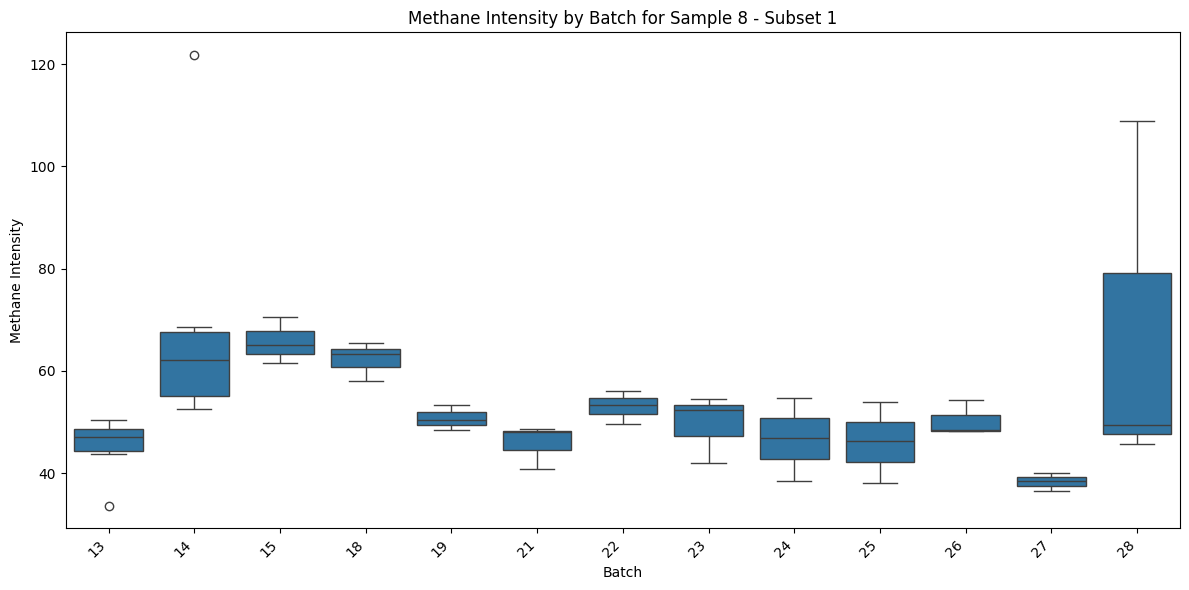

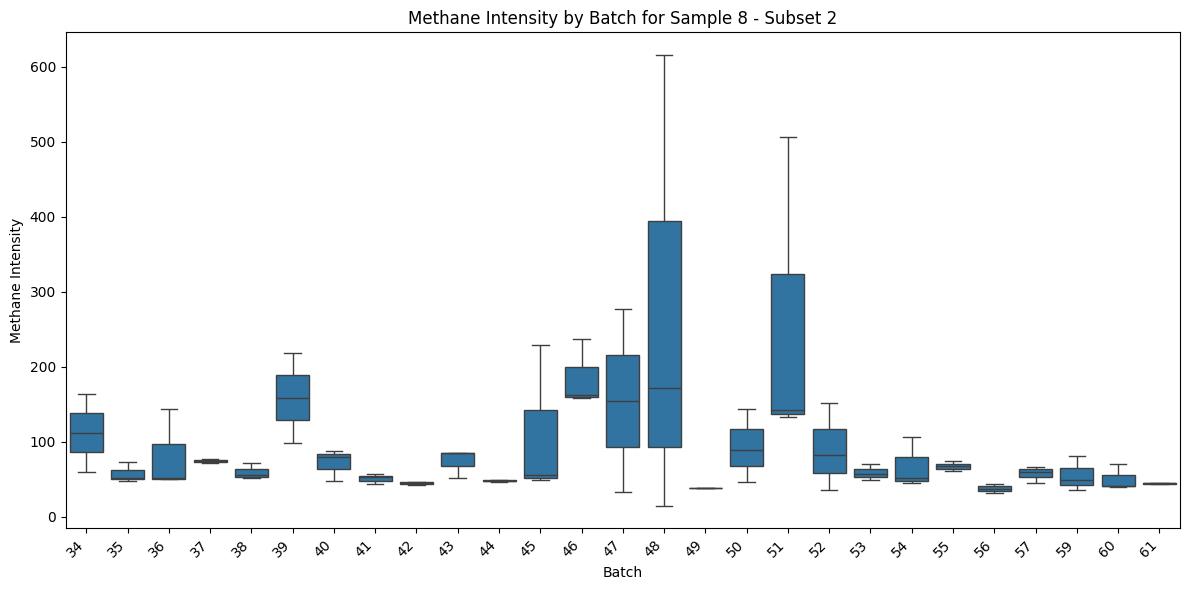

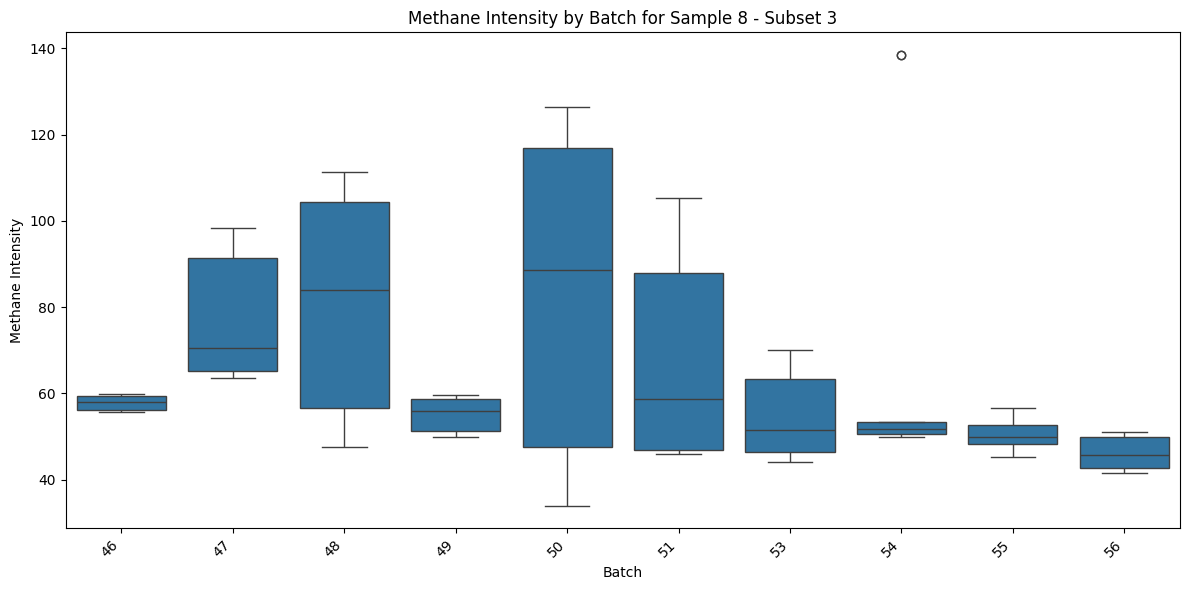

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'tddm' is numeric in df for plotting, using .loc to prevent SettingWithCopyWarning
df.loc[:, 'tddm'] = pd.to_numeric(df['methane_intensity'], errors='coerce')

# Get unique subsets from df
unique_subsets_df = df['subset'].unique()

# Loop through each unique subset in df to create boxplots
for s in unique_subsets_df:
    subset_df_filtered = df[df['subset'] == s].copy()

    # Drop rows where 'methane_intensity' is NaN after conversion
    subset_df_filtered.dropna(subset=['methane_intensity'], inplace=True)

    # Check if there's enough data for plotting after dropping NaNs and if there are multiple batches
    if not subset_df_filtered.empty and len(subset_df_filtered['batch'].unique()) > 1:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x='batch', y='methane_intensity', data=subset_df_filtered)
        plt.title(f'Methane Intensity by Batch for Sample 8 - Subset {s}')
        plt.xlabel('Batch')
        plt.ylabel('Methane Intensity')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    elif not subset_df_filtered.empty and len(subset_df_filtered['batch'].unique()) == 1:
        print(f"Skipping boxplot for Sample 8 - Subset {s}: Only one batch found ({subset_df_filtered['batch'].unique()[0]}). Boxplot requires at least two batches.")
    else:
        print(f"Skipping boxplot for Sample 8 - Subset {s}: No valid data points for 'methane_intensity' after cleaning.")

/tmp/ipykernel_27220/1039386787.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tddm'] = pd.to_numeric(df['tddm'], errors='coerce')


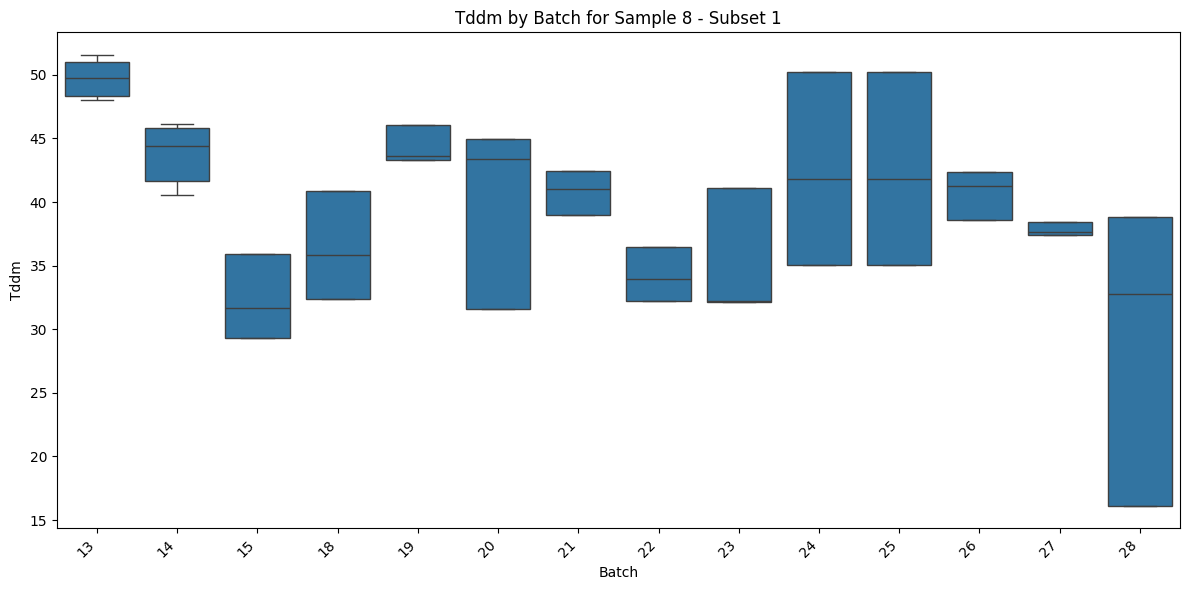

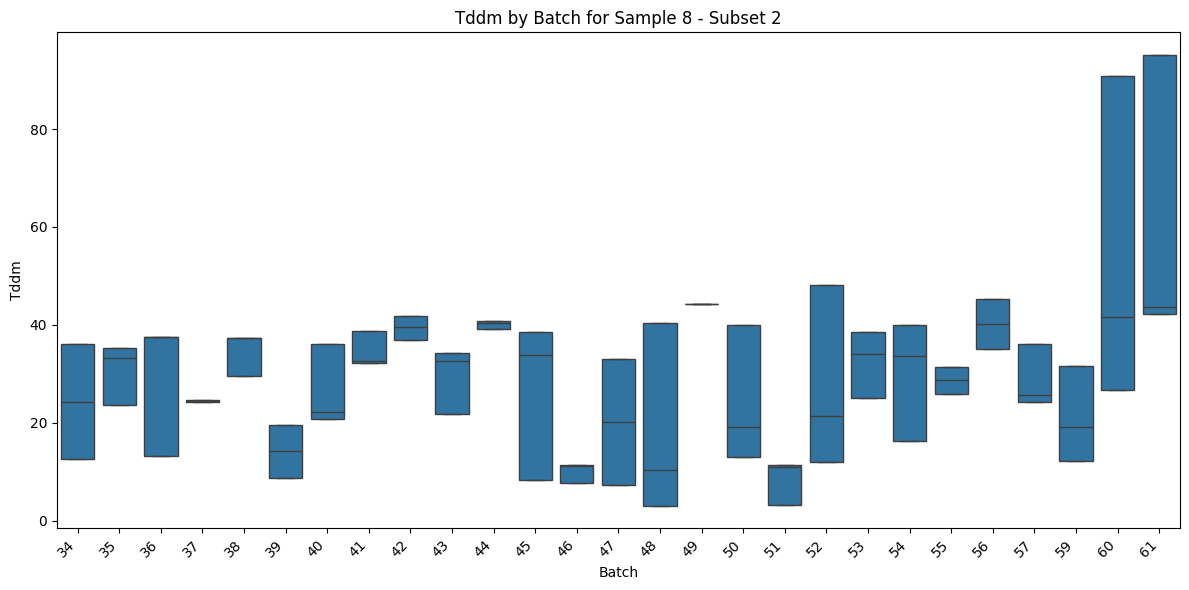

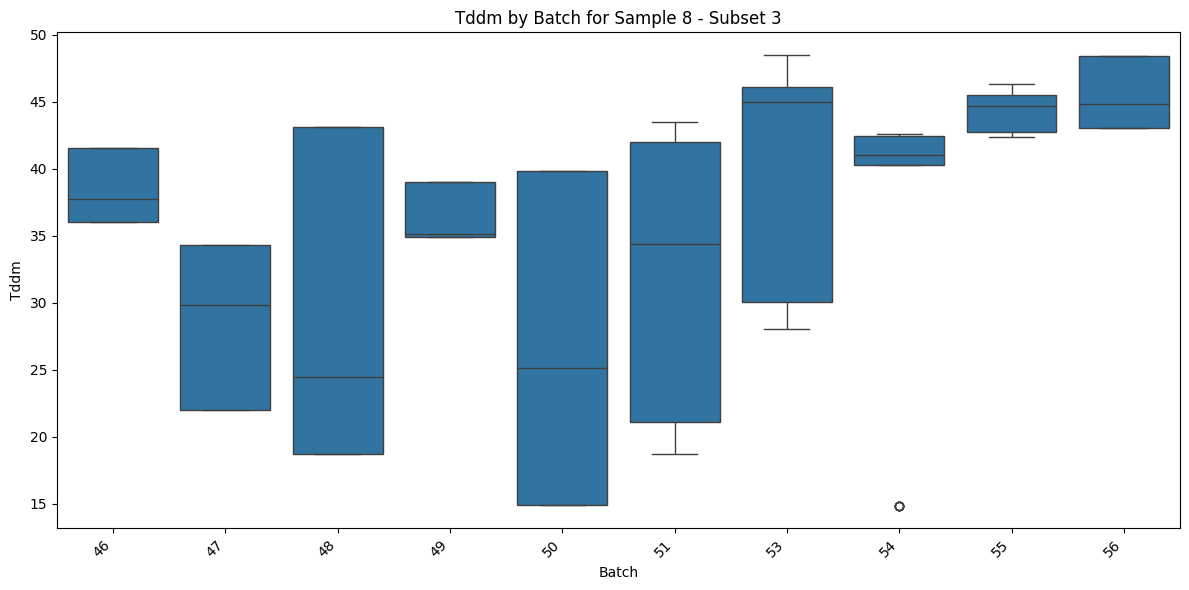

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'methane_intensity' is numeric in df for plotting
df['tddm'] = pd.to_numeric(df['tddm'], errors='coerce')

# Get unique subsets from df
unique_subsets_df = df['subset'].unique()

# Loop through each unique subset in df to create boxplots
for s in unique_subsets_df:
    subset_df_filtered = df[df['subset'] == s].copy()

    # Drop rows where 'methane_intensity' is NaN after conversion
    subset_df_filtered.dropna(subset=['tddm'], inplace=True)

    # Check if there's enough data for plotting after dropping NaNs and if there are multiple batches
    if not subset_df_filtered.empty and len(subset_df_filtered['batch'].unique()) > 1:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x='batch', y='tddm', data=subset_df_filtered)
        plt.title(f'Tddm by Batch for Sample 8 - Subset {s}')
        plt.xlabel('Batch')
        plt.ylabel('Tddm')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    elif not subset_df_filtered.empty and len(subset_df_filtered['batch'].unique()) == 1:
        print(f"Skipping boxplot for Sample 8 - Subset {s}: Only one batch found ({subset_df_filtered['batch'].unique()[0]}). Boxplot requires at least two batches.")
    else:
        print(f"Skipping boxplot for Sample 8 - Subset {s}: No valid data points for 'tddm' after cleaning.")